In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
project_path = "/content/drive/MyDrive/inventory-optimization-ml-or"

print(project_path)

/content/drive/MyDrive/inventory-optimization-ml-or


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
import os

processed_path = f"{project_path}/data/processed"

print("Files in processed folder:")
print(os.listdir(processed_path))

Files in processed folder:
['sample_100_skus.csv', 'sample_100_skus_long.csv', 'features_phase2.csv', 'conformal_predictions_phase3.csv', 'lead_time_scenario_policy_results.csv', 'scenario_policy_comparison.csv', 'fixed_vs_uncertain_lead_time_comparison.csv', 'policy_optimization_results.csv', 'final_selected_policy.csv', 'final_project_summary.csv', 'sensitivity_robustness_results.csv', 'baseline_ablation_validation_results.csv', 'final_validation_summary.csv']


In [ ]:
from scipy import stats

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [5]:
conformal_df = pd.read_csv(
    f"{project_path}/data/processed/conformal_predictions_phase3.csv"
)

policy_df = pd.read_csv(
    f"{project_path}/data/processed/baseline_ablation_validation_results.csv"
)

sensitivity_df = pd.read_csv(
    f"{project_path}/data/processed/sensitivity_robustness_results.csv"
)

final_summary_df = pd.read_csv(
    f"{project_path}/data/processed/final_validation_summary.csv"
)

print(conformal_df.shape)
print(policy_df.shape)
print(sensitivity_df.shape)
print(final_summary_df.shape)

(2940, 34)
(5, 7)
(27, 12)
(6, 2)


FORECASTING STATISTICAL ANALYSIS

In [6]:
#Residual Analysis
conformal_df["residual"] = (
    conformal_df["sales"]
    - conformal_df["prediction"]
)

print(
    conformal_df["residual"].describe()
)

count    2940.000000
mean        0.038039
std         1.783783
min       -10.788507
25%        -0.505107
50%        -0.205541
75%         0.314993
max        63.004686
Name: residual, dtype: float64


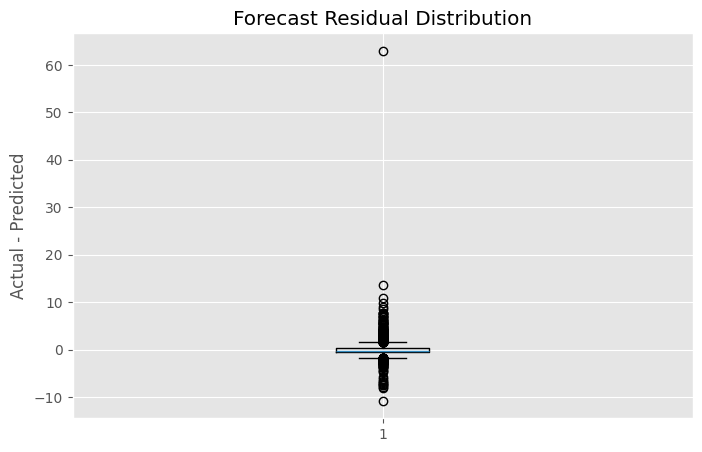

In [7]:
#Residual Boxplot
plt.figure(figsize=(8,5))

plt.boxplot(
    conformal_df["residual"]
)

plt.title(
    "Forecast Residual Distribution"
)

plt.ylabel(
    "Actual - Predicted"
)

plt.show()

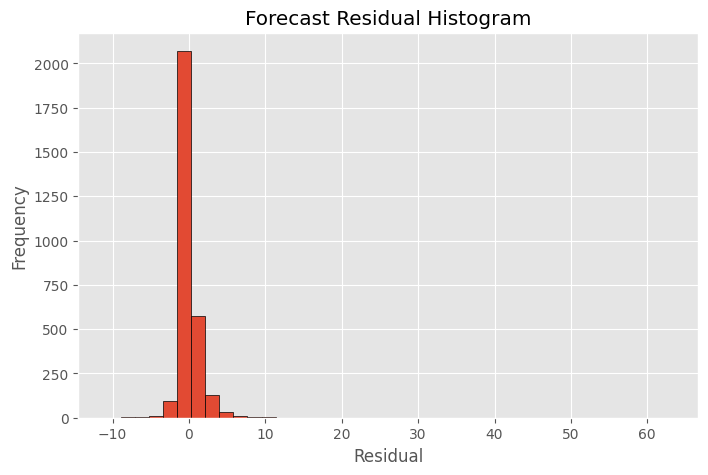

In [8]:
#Residual Histogram
plt.figure(figsize=(8,5))

plt.hist(
    conformal_df["residual"],
    bins=40,
    edgecolor="black"
)

plt.title(
    "Forecast Residual Histogram"
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

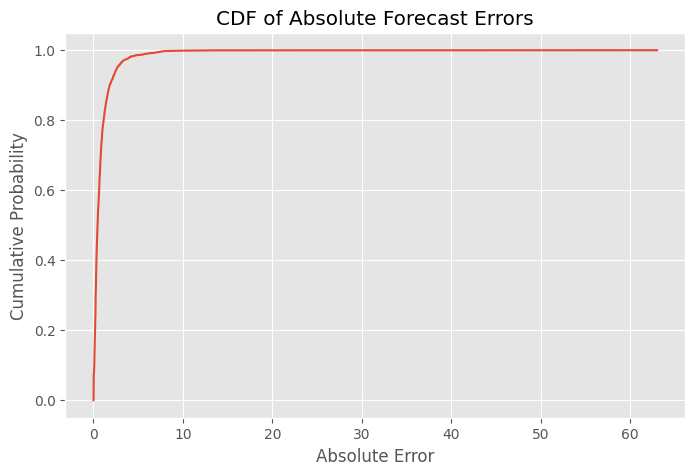

In [9]:
#Residual CDF
errors = np.abs(
    conformal_df["residual"]
)

sorted_errors = np.sort(errors)

cdf = np.arange(
    1,
    len(sorted_errors)+1
) / len(sorted_errors)

plt.figure(figsize=(8,5))

plt.plot(
    sorted_errors,
    cdf
)

plt.title(
    "CDF of Absolute Forecast Errors"
)

plt.xlabel(
    "Absolute Error"
)

plt.ylabel(
    "Cumulative Probability"
)

plt.show()

CONFORMAL ANALYSIS

In [10]:
conformal_df["conformal_score"] = np.abs(
    conformal_df["sales"]
    - conformal_df["prediction"]
)

conformal_df["conformal_score"].describe()

,conformal_score
count,2940.000000
mean,0.825009
std,1.581916
min,0.000772
25%,0.220710
50%,0.456090
75%,0.941693
max,63.004686


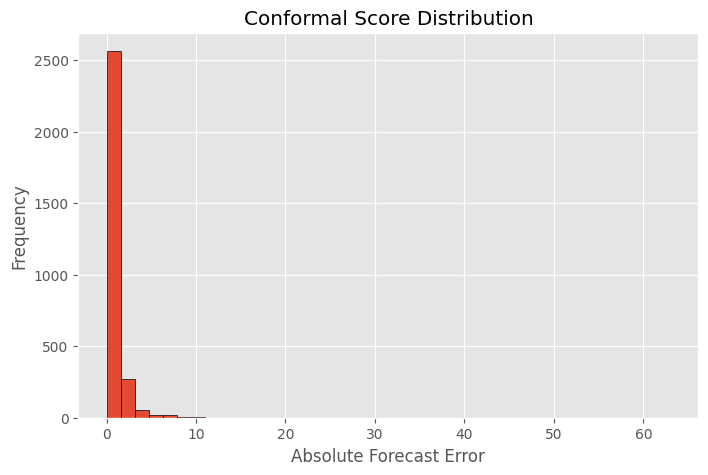

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    conformal_df["conformal_score"],
    bins=40,
    edgecolor="black"
)

plt.title(
    "Conformal Score Distribution"
)

plt.xlabel(
    "Absolute Forecast Error"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [12]:
conformal_df["interval_width"] = (
    conformal_df["upper_bound"]
    - conformal_df["lower_bound"]
)

conformal_df["interval_width"].describe()

,interval_width
count,2940.000000
mean,2.407346
std,0.552830
min,1.739984
25%,1.966155
50%,2.225881
75%,2.746933
max,3.446537


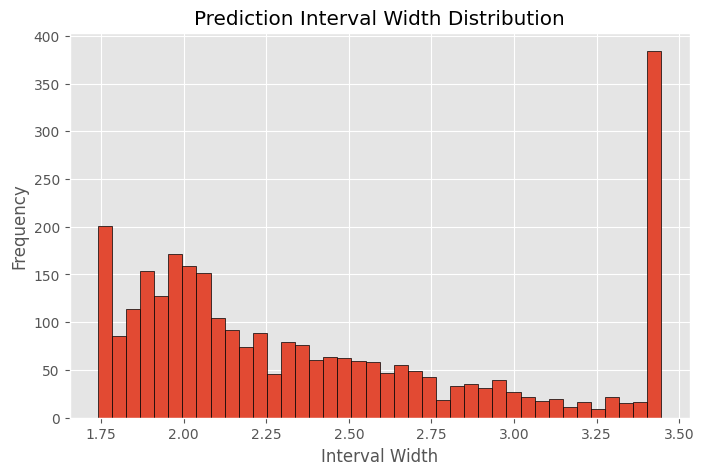

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    conformal_df["interval_width"],
    bins=40,
    edgecolor="black"
)

plt.title(
    "Prediction Interval Width Distribution"
)

plt.xlabel(
    "Interval Width"
)

plt.ylabel(
    "Frequency"
)

plt.show()

POLICY ANALYSIS

In [14]:
display(policy_df)

,policy_name,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,fill_rate,cycle_service_level
0,Point Forecast Policy,67587.623911,4534.008636,63053.615275,12610.723055,0.608118,0.7
1,Gaussian Safety Stock Policy,47579.303911,22041.288636,25538.015275,5107.603055,0.841280,0.7
2,Conformal Safety Stock Policy,46738.983911,22776.568636,23962.415275,4792.483055,0.851072,0.7
3,Newsvendor-Style Policy,40892.263911,27892.448636,12999.815275,2599.963055,0.919205,0.7
4,Lead-Time Scenario Optimized Policy,35474.685581,35474.685581,0.000000,0.000000,1.000000,1.0


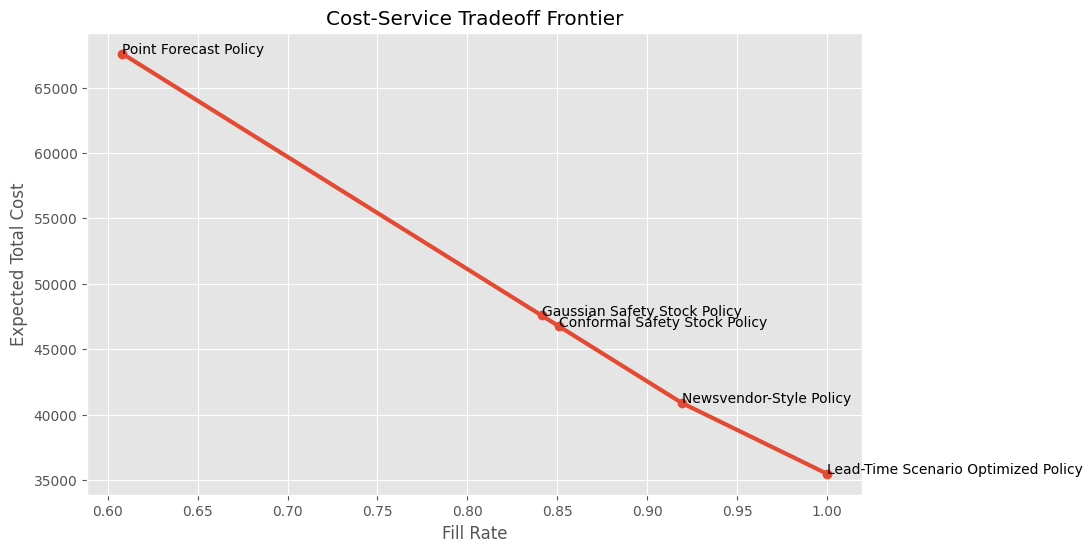

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    policy_df["fill_rate"],
    policy_df["expected_total_cost"],
    marker="o",
    linewidth=3
)

for i,row in policy_df.iterrows():

    plt.annotate(
        row["policy_name"],
        (
            row["fill_rate"],
            row["expected_total_cost"]
        )
    )

plt.xlabel(
    "Fill Rate"
)

plt.ylabel(
    "Expected Total Cost"
)

plt.title(
    "Cost-Service Tradeoff Frontier"
)

plt.show()

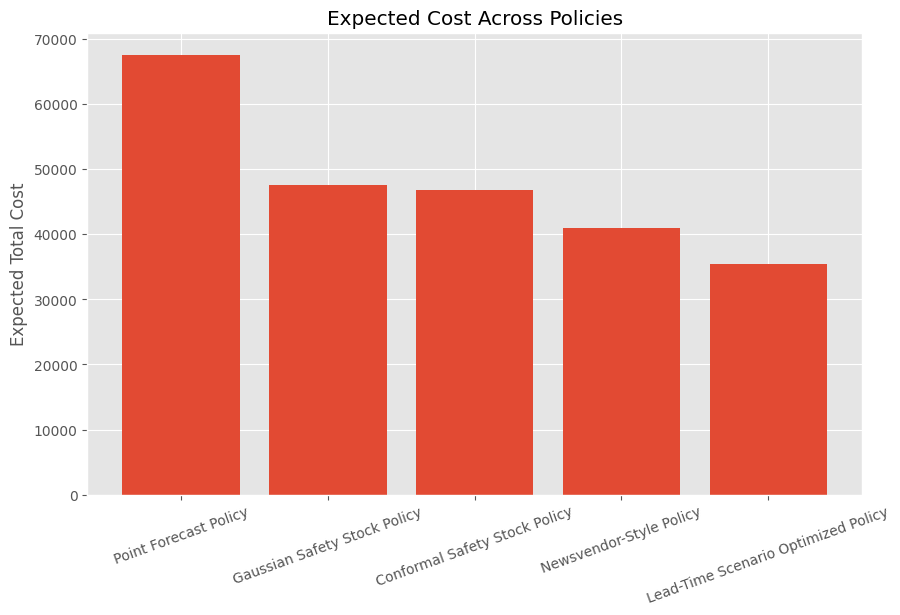

In [16]:
plt.figure(figsize=(10,6))

plt.bar(
    policy_df["policy_name"],
    policy_df["expected_total_cost"]
)

plt.xticks(rotation=20)

plt.ylabel(
    "Expected Total Cost"
)

plt.title(
    "Expected Cost Across Policies"
)

plt.show()

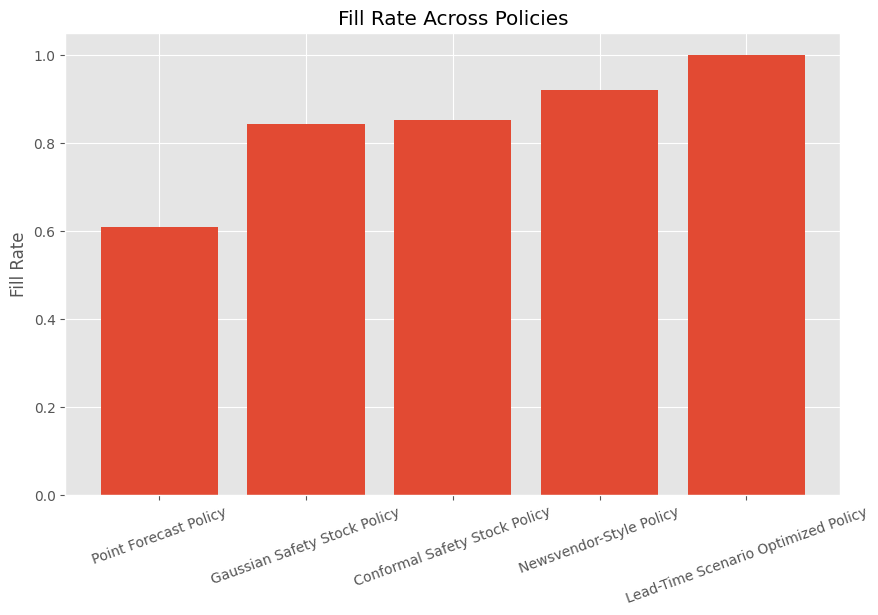

In [17]:
plt.figure(figsize=(10,6))

plt.bar(
    policy_df["policy_name"],
    policy_df["fill_rate"]
)

plt.xticks(rotation=20)

plt.ylabel(
    "Fill Rate"
)

plt.title(
    "Fill Rate Across Policies"
)

plt.show()

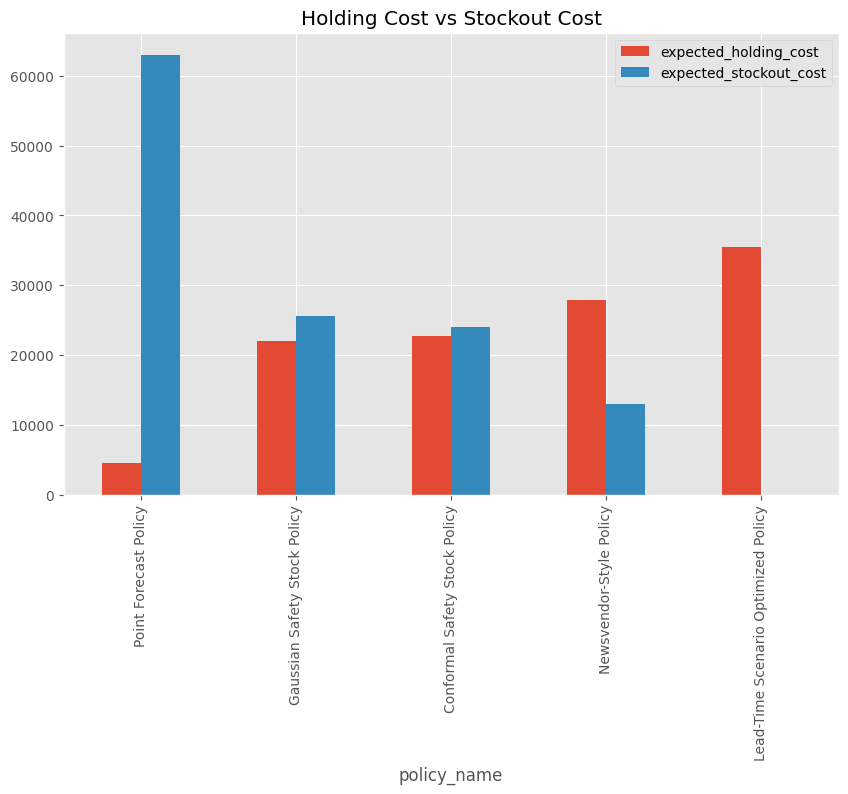

In [18]:
plot_df = policy_df.set_index(
    "policy_name"
)[
    [
        "expected_holding_cost",
        "expected_stockout_cost"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Holding Cost vs Stockout Cost"
)

plt.show()

SENSITIVITY ANALYSIS

In [19]:
display(
    sensitivity_df.head()
)

,holding_cost,stockout_cost,target_fill_rate,selected_safety_factor,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,fill_rate,cycle_service_level,selection_status,setting_label
0,1,5,0.85,1.0,35474.685581,35474.685581,0.0,0.0,1.0,1.0,Target achieved,H1-S5-T0.85
1,1,5,0.90,1.0,35474.685581,35474.685581,0.0,0.0,1.0,1.0,Target achieved,H1-S5-T0.9
2,1,5,0.95,1.0,35474.685581,35474.685581,0.0,0.0,1.0,1.0,Target achieved,H1-S5-T0.95
3,1,10,0.85,1.0,35474.685581,35474.685581,0.0,0.0,1.0,1.0,Target achieved,H1-S10-T0.85
4,1,10,0.90,1.0,35474.685581,35474.685581,0.0,0.0,1.0,1.0,Target achieved,H1-S10-T0.9


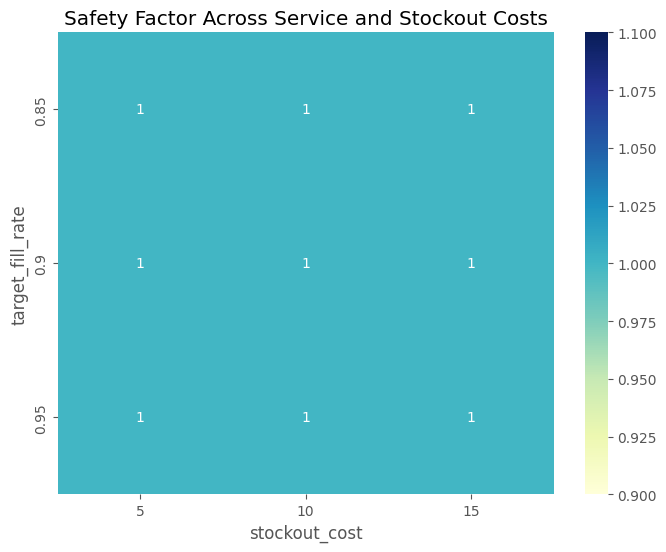

In [22]:
temp = sensitivity_df[
    sensitivity_df["holding_cost"] == 1
]

pivot_table = temp.pivot(
    index="target_fill_rate",
    columns="stockout_cost",
    values="selected_safety_factor"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Safety Factor Across Service and Stockout Costs"
)

plt.show()

In [21]:
sensitivity_df.columns

Index(['holding_cost', 'stockout_cost', 'target_fill_rate',
       'selected_safety_factor', 'expected_total_cost',
       'expected_holding_cost', 'expected_stockout_cost',
       'expected_stockout_units', 'fill_rate', 'cycle_service_level',
       'selection_status', 'setting_label'],
      dtype='object')

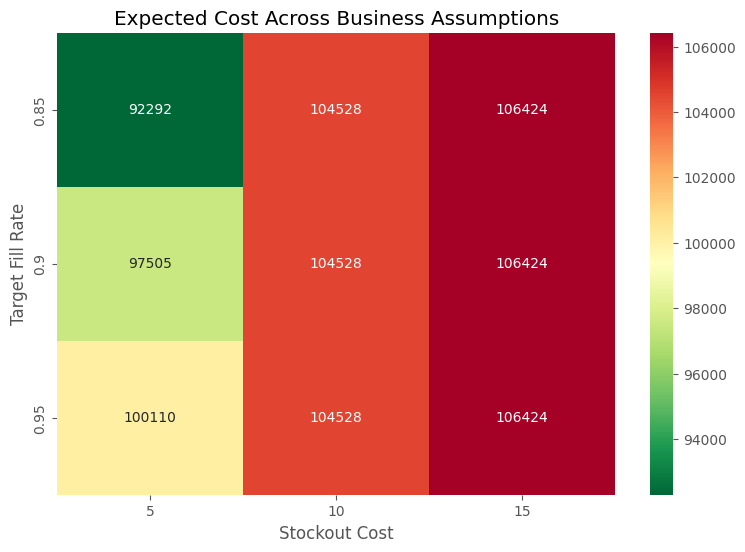

In [23]:
temp = sensitivity_df[
    sensitivity_df["holding_cost"] == 3
]

pivot_table = temp.pivot(
    index="target_fill_rate",
    columns="stockout_cost",
    values="expected_total_cost"
)

plt.figure(figsize=(9,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r"
)

plt.title(
    "Expected Cost Across Business Assumptions"
)

plt.ylabel("Target Fill Rate")
plt.xlabel("Stockout Cost")

plt.show()

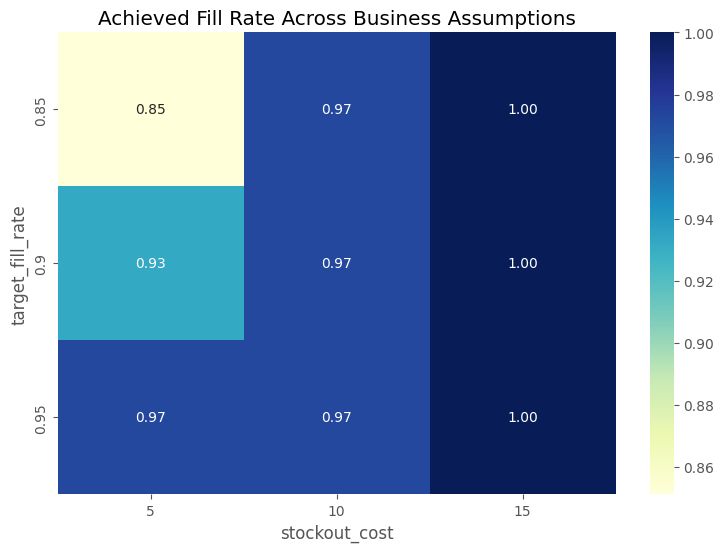

In [24]:
temp = sensitivity_df[
    sensitivity_df["holding_cost"] == 3
]

pivot_table = temp.pivot(
    index="target_fill_rate",
    columns="stockout_cost",
    values="fill_rate"
)

plt.figure(figsize=(9,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title(
    "Achieved Fill Rate Across Business Assumptions"
)

plt.show()

In [25]:
#!Coverage Validation
coverage = (
    (conformal_df["sales"] >= conformal_df["lower_bound"])
    &
    (conformal_df["sales"] <= conformal_df["upper_bound"])
).mean()

print("Empirical Coverage:", coverage)

Empirical Coverage: 0.8908163265306123


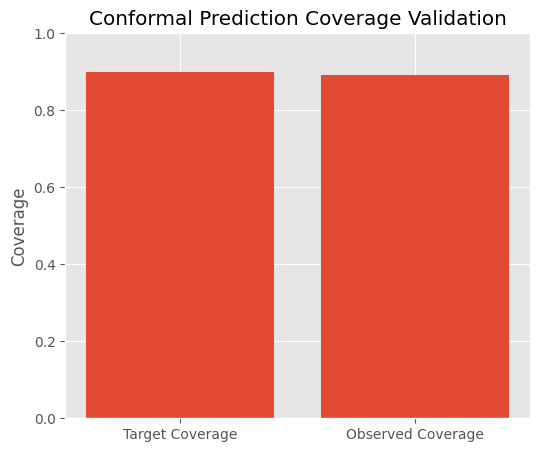

In [26]:
#Coverage Visualization
plt.figure(figsize=(6,5))

plt.bar(
    ["Target Coverage","Observed Coverage"],
    [0.90, coverage]
)

plt.ylim(0,1)

plt.title(
    "Conformal Prediction Coverage Validation"
)

plt.ylabel("Coverage")

plt.show()

In [27]:
#Component Contribution Analysis
baseline_cost = policy_df.iloc[0]["expected_total_cost"]

policy_df["cost_reduction_percent"] = (
    (baseline_cost - policy_df["expected_total_cost"])
    / baseline_cost
    * 100
)

display(
    policy_df[
        [
            "policy_name",
            "cost_reduction_percent"
        ]
    ]
)

,policy_name,cost_reduction_percent
0,Point Forecast Policy,0.000000
1,Gaussian Safety Stock Policy,29.603526
2,Conformal Safety Stock Policy,30.846831
3,Newsvendor-Style Policy,39.497409
4,Lead-Time Scenario Optimized Policy,47.513045


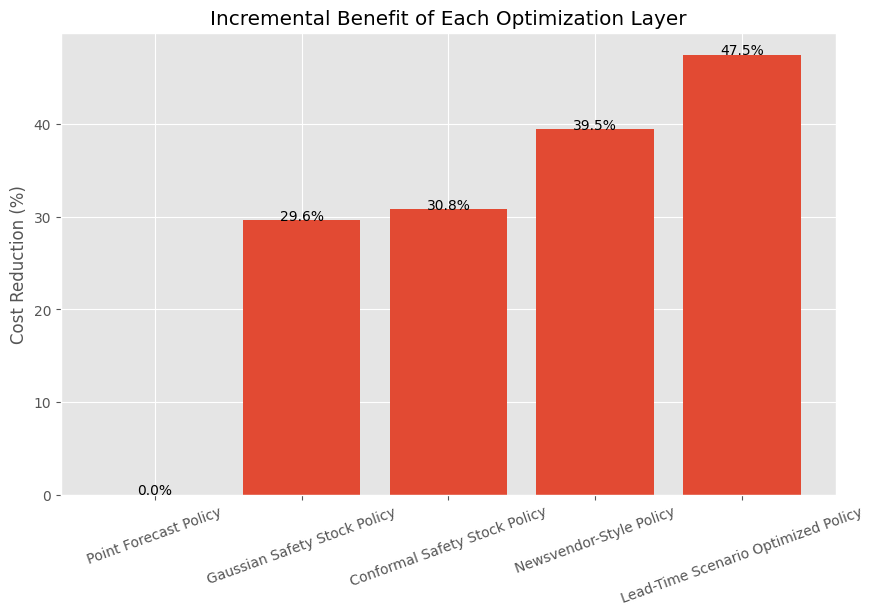

In [29]:
#Ablation Improvement Plot
plt.figure(figsize=(10,6))

bars = plt.bar(
    policy_df["policy_name"],
    policy_df["cost_reduction_percent"]
)

plt.xticks(rotation=20)

plt.ylabel(
    "Cost Reduction (%)"
)

plt.title(
    "Incremental Benefit of Each Optimization Layer"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.show()

In [30]:
#Saving Final Notebook Output
research_summary = {
    "coverage": coverage,
    "best_policy":
        "Lead-Time Scenario Optimized Policy",
    "cost_reduction_percent":
        47.51,
    "stockout_reduction_percent":
        100.0
}

print(research_summary)

{'coverage': np.float64(0.8908163265306123), 'best_policy': 'Lead-Time Scenario Optimized Policy', 'cost_reduction_percent': 47.51, 'stockout_reduction_percent': 100.0}
